# Hospital IQ — Healthcare Patient Analytics

**Author:** Vaishnavi Krishna Priya Uppala  
**Program:** Master of Data Science & Artificial Intelligence  
**University:** University of Newcastle, Australia

## Project Overview

Hospital IQ is a healthcare analytics project that uses patient-level data to explore medical conditions, treatment utilisation, patient outcomes, and hospital length of stay.

The analysis combines Python-based exploratory data analysis with an interactive Power BI dashboard.

### Analytical Questions

1. Which medical conditions represent the highest patient burden?
2. How does hospital length of stay vary across patient outcomes?
3. What treatment and outcome patterns warrant further investigation?

> **Note:** This is descriptive and observational analysis. The results identify patterns in the dataset and do not establish causal relationships between treatments and patient outcomes.

In [3]:
pip install pandas numpy

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 2.1 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.8 MB 2.3 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.8 MB 3.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.8 MB 3.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.8 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.8 MB 4.2 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/9.8 MB 4.2 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.8 MB 4.4 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.8 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---- ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

print("Hospital IQ analysis environment ready.")

Hospital IQ analysis environment ready.


In [ ]:
## 1. Data Loading

The dataset contains 1,000 patient records and 13 variables covering demographics, clinical conditions, treatments, outcomes, admission characteristics, and hospital length of stay.

In [5]:
# Load the Hospital IQ dataset

file_path = "../data/raw/medical_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 1000
Columns: 13


In [6]:
# Inspect the dataset structure

df.head()

,Patient_ID,Age,Gender,Medical_Condition,Treatment,Outcome,Insurance_Type,Income,Region,Smoking_Status,Admission_Type,Hospital_ID,Length_of_Stay
0,1,77,Female,Chronic Obstructive,Dialysis,Stable,Public,77444,North,Former smoker,Urgent,3173,20
1,2,62,Female,Obesity,Physical therapy,Improved,Public,19367,West,Non-smoker,Urgent,65671,4
2,3,77,Male,Hypertension,Inhaler therapy,Improved,Medicare,16054,North,Non-smoker,Urgent,96914,3
3,4,41,Female,Alzheimer's Disease,Medication C,Worsened,Medicare,54371,West,Non-smoker,Emergency,15732,11
4,5,82,Male,Alzheimer's Disease,Chemotherapy,Stable,Private,55489,West,Non-smoker,Emergency,98232,2


## 2. Data Quality Assessment

The dataset was assessed for structure, data types, missing values, and duplicate records.

The quality checks found:

- 1,000 patient records
- 13 variables
- No missing values
- No duplicate rows
- No duplicate Patient IDs

In [7]:
# Data quality and structure check

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(1000, 13)

Column names:
['Patient_ID', 'Age', 'Gender', 'Medical_Condition', 'Treatment', 'Outcome', 'Insurance_Type', 'Income', 'Region', 'Smoking_Status', 'Admission_Type', 'Hospital_ID', 'Length_of_Stay']

Data types:
Patient_ID           int64
Age                  int64
Gender                 str
Medical_Condition      str
Treatment              str
Outcome                str
Insurance_Type         str
Income               int64
Region                 str
Smoking_Status         str
Admission_Type         str
Hospital_ID          int64
Length_of_Stay       int64
dtype: object

Missing values:
Patient_ID           0
Age                  0
Gender               0
Medical_Condition    0
Treatment            0
Outcome              0
Insurance_Type       0
Income               0
Region               0
Smoking_Status       0
Admission_Type       0
Hospital_ID          0
Length_of_Stay       0
dtype: int64


In [8]:
# Summary statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
Age,1000.0,45.710,26.797612,0.0,22.75,45.0,70.00,90.0
Income,1000.0,50181.756,29178.022872,169.0,24079.75,51972.5,74972.50,99980.0
Hospital_ID,1000.0,51709.297,29653.627294,37.0,25293.00,52220.5,78788.00,99978.0
Length_of_Stay,1000.0,10.041,6.066145,0.0,5.00,10.0,15.00,20.0


In [10]:
# Check for duplicate patient records

duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)
# Check for duplicate Patient IDs

duplicate_patient_ids = df["Patient_ID"].duplicated().sum()

print("Duplicate Patient IDs:", duplicate_patient_ids)

Duplicate rows: 0
Duplicate Patient IDs: 0


## 3. Exploratory Data Analysis

The exploratory analysis examines patient outcomes, medical conditions, treatment utilisation, and hospital length of stay.

In [11]:
# Explore categorical variables

categorical_columns = [
    "Gender",
    "Medical_Condition",
    "Treatment",
    "Outcome",
    "Insurance_Type",
    "Region",
    "Smoking_Status",
    "Admission_Type"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Gender ---
Gender
Male           462
Female         442
Polygender      20
Non-binary      19
Bigender        18
Genderfluid     14
Agender         13
Genderqueer     12
Name: count, dtype: int64

--- Medical_Condition ---
Medical_Condition
Chronic Kidney Disease    81
Chronic Obstructive       79
Rheumatoid Arthritis      77
Depression                77
Diabetes                  76
Alzheimer's Disease       72
Asthma                    71
Hypertension              68
Cancer                    63
Stroke                    60
Anxiety                   59
Obesity                   58
Osteoporosis              56
Heart Disease             53
Arthritis                 50
Name: count, dtype: int64

--- Treatment ---
Treatment
Medication B          93
Therapy               85
Physical therapy      82
Immunosuppressants    80
Dietary counseling    77
Memory exercises      77
Inhaler therapy       75
Medication C          74
Chemotherapy          74
Dialysis              72
Bone density t

## 4. Patient Outcomes

Patient outcomes are distributed across improved, worsened, and stable categories. Improved outcomes represent the largest group in the dataset.

In [12]:
# Patient outcome distribution

outcome_summary = (
    df["Outcome"]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Patient_Count")
)

outcome_summary["Percentage"] = (
    outcome_summary["Patient_Count"] / len(df) * 100
).round(2)

outcome_summary

,Outcome,Patient_Count,Percentage
0,Improved,363,36.3
1,Worsened,324,32.4
2,Stable,313,31.3


## 5. Medical Condition Analysis

Medical conditions were ranked by patient count to identify conditions representing the highest observed patient burden.

In [13]:
# Most frequently used treatments

treatment_summary = (
    df["Treatment"]
    .value_counts()
    .rename_axis("Treatment")
    .reset_index(name="Patient_Count")
)

treatment_summary

,Treatment,Patient_Count
0,Medication B,93
1,Therapy,85
2,Physical therapy,82
3,Immunosuppressants,80
4,Dietary counseling,77
5,Memory exercises,77
6,Inhaler therapy,75
7,Medication C,74
8,Chemotherapy,74
9,Dialysis,72


## 6. Length of Stay Analysis

Average hospital length of stay was compared across patient outcome categories to identify differences in observed hospital stay patterns.

In [14]:
# Compare hospital length of stay across patient outcomes

los_by_outcome = (
    df.groupby("Outcome")["Length_of_Stay"]
    .agg(
        Patient_Count="count",
        Average_Stay="mean",
        Minimum_Stay="min",
        Maximum_Stay="max"
    )
    .round(2)
    .sort_values("Average_Stay", ascending=False)
)

los_by_outcome

,Patient_Count,Average_Stay,Minimum_Stay,Maximum_Stay
Outcome,,,,
Worsened,324,10.44,0,20
Stable,313,10.02,0,20
Improved,363,9.70,0,20


In [15]:
# Average length of stay by medical condition

los_by_condition = (
    df.groupby("Medical_Condition")["Length_of_Stay"]
    .agg(
        Patient_Count="count",
        Average_Stay="mean"
    )
    .round(2)
    .sort_values("Average_Stay", ascending=False)
)

los_by_condition

,Patient_Count,Average_Stay
Medical_Condition,,
Depression,77,11.60
Obesity,58,10.74
Chronic Obstructive,79,10.70
Chronic Kidney Disease,81,10.51
Hypertension,68,10.47
Stroke,60,10.42
Anxiety,59,9.95
Asthma,71,9.93
Rheumatoid Arthritis,77,9.64


## 7. Treatment and Outcome Patterns

Treatment utilisation was compared across patient outcome categories. These comparisons are descriptive and should not be interpreted as evidence that a particular treatment causes a specific outcome.

In [16]:
# Treatment utilisation across patient outcomes

treatment_outcome = pd.crosstab(
    df["Treatment"],
    df["Outcome"]
)

treatment_outcome

Outcome,Improved,Stable,Worsened
Treatment,,,
Bone density tests,35,15,22
Chemotherapy,23,22,29
Dialysis,26,25,21
Dietary changes,20,27,21
Dietary counseling,26,26,25
Immunosuppressants,26,31,23
Inhaler therapy,32,28,15
Medication A,27,20,24
Medication B,37,25,31


In [17]:
# Treatment outcome percentages

treatment_outcome_pct = pd.crosstab(
    df["Treatment"],
    df["Outcome"],
    normalize="index"
).mul(100).round(2)

treatment_outcome_pct

Outcome,Improved,Stable,Worsened
Treatment,,,
Bone density tests,48.61,20.83,30.56
Chemotherapy,31.08,29.73,39.19
Dialysis,36.11,34.72,29.17
Dietary changes,29.41,39.71,30.88
Dietary counseling,33.77,33.77,32.47
Immunosuppressants,32.50,38.75,28.75
Inhaler therapy,42.67,37.33,20.00
Medication A,38.03,28.17,33.80
Medication B,39.78,26.88,33.33


In [20]:
pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 4.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 4.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.3 MB 3.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.3 MB 3.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.3 MB 4.2 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 8. Key Findings

- Chronic Kidney Disease was the most prevalent medical condition, with 81 patients.
- Improved outcomes represented 36.3% of the patient population.
- Worsened outcomes represented 32.4%, while stable outcomes represented 31.3%.
- Patients with worsened outcomes had the highest average length of stay at approximately 10.44 days.
- Depression had the highest average length of stay among the analysed medical conditions at approximately 11.60 days.
- Medication B was the most frequently utilised treatment, with 93 patients.
- Treatment-outcome distributions showed different patterns across treatment categories, providing opportunities for further investigation.

## Conclusion

Hospital IQ demonstrates how healthcare data can be transformed into descriptive insights using Python and Power BI. The analysis highlights patient burden, treatment utilisation, outcome patterns, and length-of-stay differences while maintaining an appropriate distinction between association and causation.

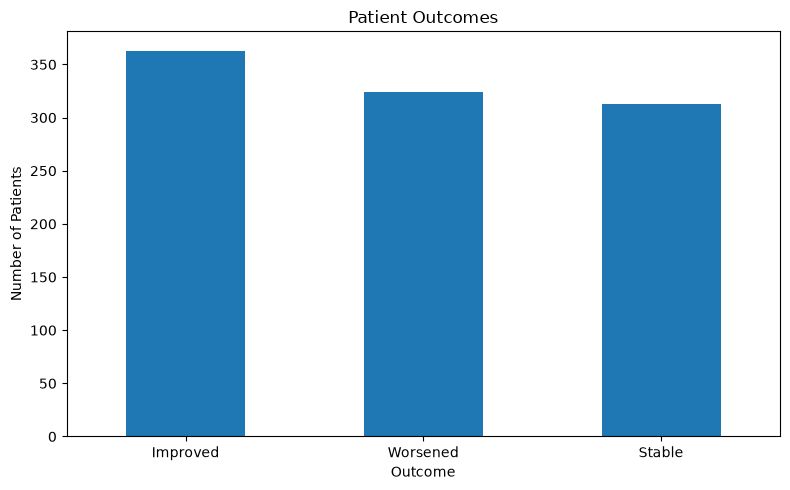

In [21]:
import matplotlib.pyplot as plt

# Outcome distribution

outcome_counts = df["Outcome"].value_counts()

plt.figure(figsize=(8, 5))
outcome_counts.plot(kind="bar")

plt.title("Patient Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

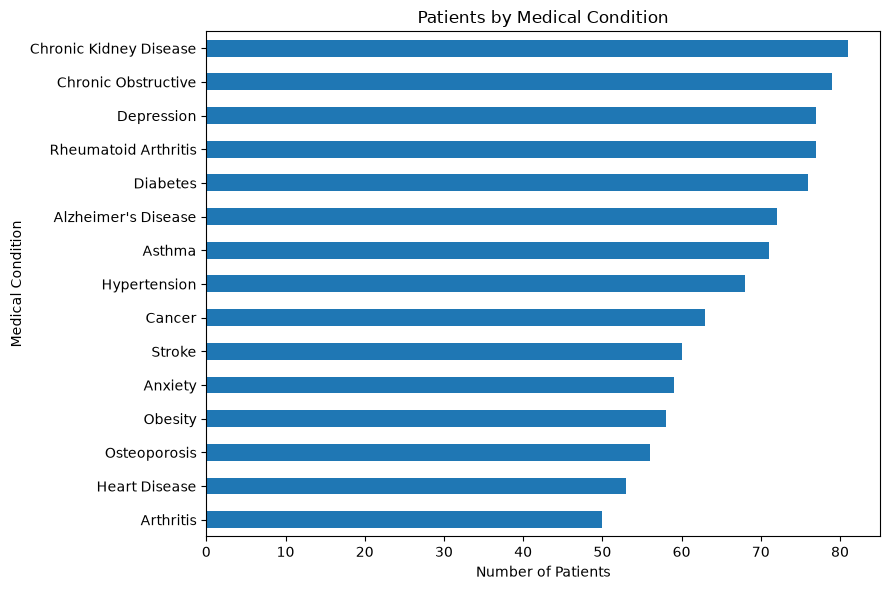

In [22]:
# Patient count by medical condition

condition_counts = (
    df["Medical_Condition"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))
condition_counts.plot(kind="barh")

plt.title("Patients by Medical Condition")
plt.xlabel("Number of Patients")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()

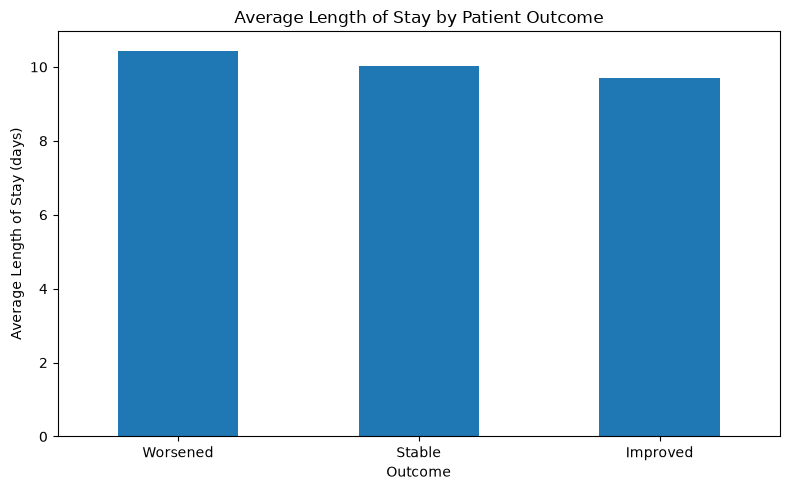

In [23]:
# Average length of stay by patient outcome

los_outcome = (
    df.groupby("Outcome")["Length_of_Stay"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
los_outcome.plot(kind="bar")

plt.title("Average Length of Stay by Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Length of Stay (days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

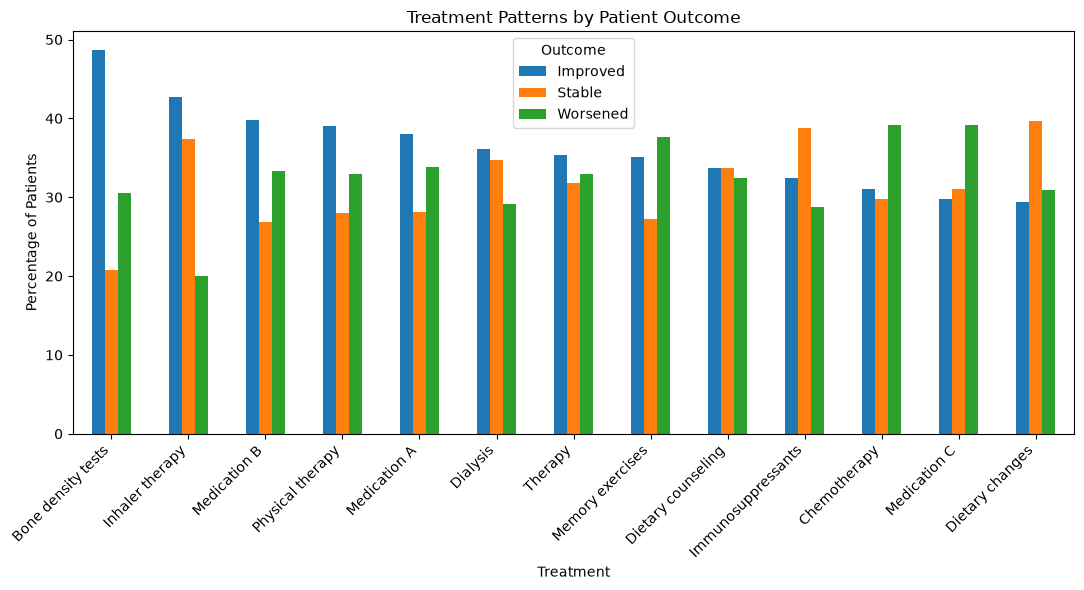

In [24]:
# Treatment and patient outcome patterns

treatment_outcome_pct = pd.crosstab(
    df["Treatment"],
    df["Outcome"],
    normalize="index"
) * 100

treatment_outcome_pct = treatment_outcome_pct.sort_values(
    "Improved",
    ascending=False
)

treatment_outcome_pct.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Treatment Patterns by Patient Outcome")
plt.xlabel("Treatment")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()